<a href="https://colab.research.google.com/github/suryasai99/Object_detection/blob/main/anchor_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import requests
from zipfile import ZipFile
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import cv2

np.random.seed(42)

In [2]:
def download_file(url, save_name):
    """
    "Download and save the file."

    arguments:
    url (str): URL path of the file.
    save_name: (str): file path to save the downloaded file.
    """
    file = requests.get(url)
    open(save_name, 'wb').write(file.content)
    print(f"Downloaded {save_name}...")
    return

In [3]:
def unzip(zip_file_path=None):
    """
    "Unzip the file"

    arguments:
    zip_file_path (str): The zipped file path

    """
    try:
        with ZipFile(zip_file_path) as z:
            z.extractall("./")
            print(f"Extracted {zip_file_path}...\n")
    except:
        print("Invalid file")

    return

In [4]:
if not os.path.exists('encoder_scripts'):
    download_file(
                  'https://www.dropbox.com/s/7yo1bx7vy92wefg/encoder_scripts.zip?dl=1',
                  'encoder_scripts.zip'
                 )

    unzip('encoder_scripts.zip')

In [5]:
os.listdir("./encoder_scripts")

['general_encoder.py', 'train_boxes.csv', 'encoder.py']

### Get the bounding box info from the training data

In [6]:
train_boxes_info = pd.read_csv('/content/encoder_scripts/train_boxes.csv')
print(train_boxes_info)

           xmin        ymin       xmax       ymax
0     85.867620  101.865680  162.07513  241.23135
1    225.402510   95.708954  287.11987  272.01492
2     44.835167   67.391304  125.93407  275.36234
3    183.507310   91.011240  279.95825  283.82022
4    168.358220   51.453487  286.56717  293.02325
..          ...         ...        ...        ...
350   86.729860   23.209170  181.99052  276.79083
351  113.085940   40.000000  175.78125  269.60000
352  187.500000   44.000000  253.12500  268.00000
353    6.122449   34.441086  105.10204  293.65558
354  103.061226   23.564955  210.20409  292.74924

[355 rows x 4 columns]


In [7]:
# To add height and width to the csv file
train_boxes_info['width'] = train_boxes_info['xmax'] - train_boxes_info['xmin']
train_boxes_info['height'] = train_boxes_info['ymax'] - train_boxes_info['ymin']
print(train_boxes_info)

           xmin        ymin       xmax       ymax       width      height
0     85.867620  101.865680  162.07513  241.23135   76.207510  139.365670
1    225.402510   95.708954  287.11987  272.01492   61.717360  176.305966
2     44.835167   67.391304  125.93407  275.36234   81.098903  207.971036
3    183.507310   91.011240  279.95825  283.82022   96.450940  192.808980
4    168.358220   51.453487  286.56717  293.02325  118.208950  241.569763
..          ...         ...        ...        ...         ...         ...
350   86.729860   23.209170  181.99052  276.79083   95.260660  253.581660
351  113.085940   40.000000  175.78125  269.60000   62.695310  229.600000
352  187.500000   44.000000  253.12500  268.00000   65.625000  224.000000
353    6.122449   34.441086  105.10204  293.65558   98.979591  259.214494
354  103.061226   23.564955  210.20409  292.74924  107.142864  269.184285

[355 rows x 6 columns]


In [8]:
# Visualizing the kmeans cluster
class VisulaizeScatter:
  def __init__(self, figsize=(12, 8),
               xlabel = 'Width', ylabel = 'Height',
               title = None):
    plt.figure(figsize = figsize)
    plt.grid('true')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

  @staticmethod
  def add_scatter(x, y,
                  color = 'blue', size = 15):
    plt.scatter(x, y, c = color, s = size)

  @staticmethod
  def show_plot():
    plt.show()

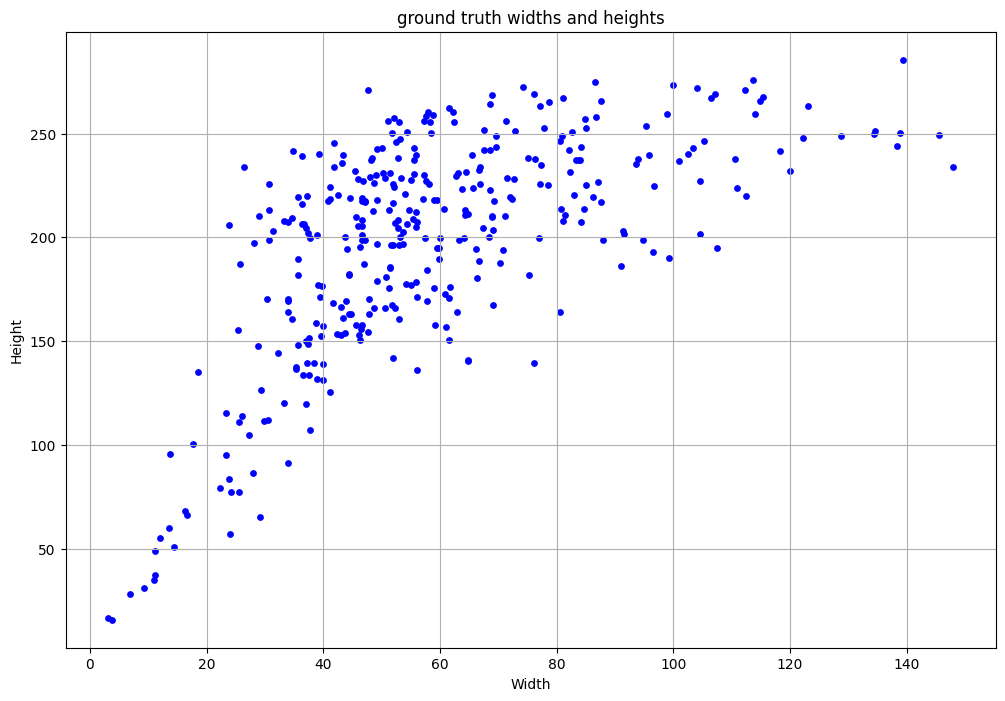

In [9]:
vis = VisulaizeScatter(title = 'ground truth widths and heights')
vis.add_scatter(train_boxes_info['width'], train_boxes_info['height'])
vis.show_plot()

## Apply kmeans on width-height datapoints


In [10]:
# Initiate kmeans for 20 clusters
kmeans = KMeans(n_clusters = 20, n_init = 'auto', random_state = 42)
# prepare the dataset
data = np.stack([train_boxes_info['width'], train_boxes_info['height']], axis = 1)
# training
kmeans.fit(data)
# cluster centers
centroids = kmeans.cluster_centers_

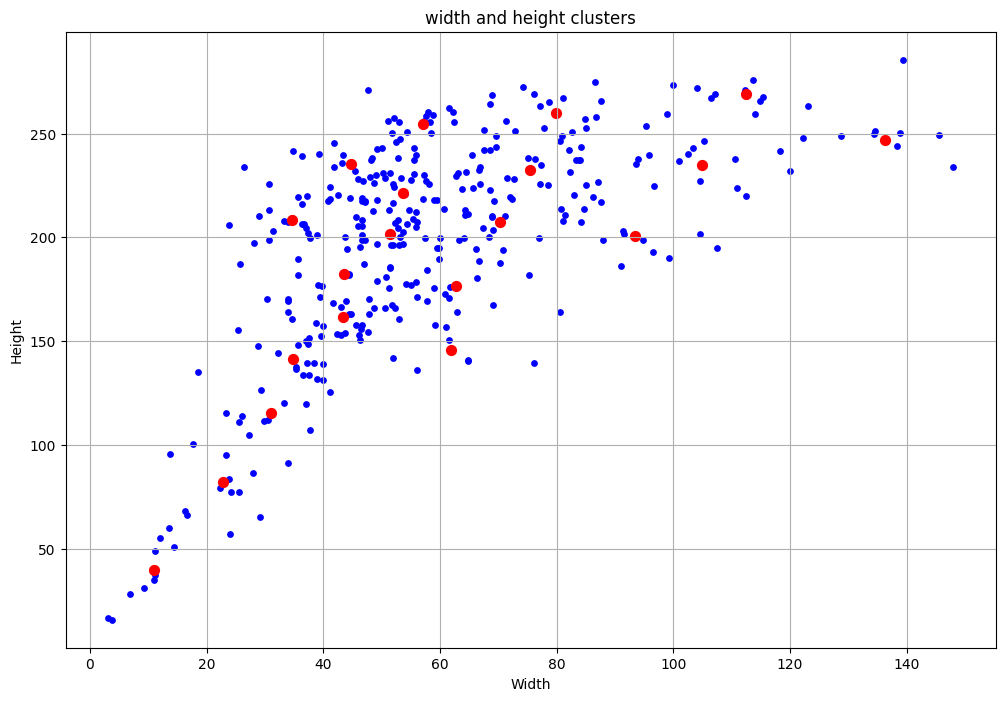

In [11]:
vis = VisulaizeScatter(title = 'width and height clusters')
vis.add_scatter(data[:,0], data[:, 1],
                color = 'blue', size = 15)
vis.add_scatter(centroids[:, 0], centroids[:, 1],
                color = 'red', size = 50)
vis.show_plot()

## use centroids as anchors

In [12]:
# calculate area
areas = centroids[:, 0] * centroids[:,1]
# Indices for the sorted areas
args_areas = np.argsort(areas)
# anchor width-height
anchor_wh = centroids[args_areas]
# split into five groups for the five-level feature map
fm_anchors_wh = np.array_split(anchor_wh, 5)

# Lets store anchors in a dictionary
anchors_wh = dict()
feature_level_keys = ['38x38', '19x19', '10x10', '5x5', '3x3']
for i, anchor_wh in enumerate(fm_anchors_wh):
  key = feature_level_keys[i]
  anchors_wh[key] = anchor_wh
  print(f"{key}:\n{anchor_wh}")

38x38:
[[ 10.91160245  39.68406864]
 [ 22.8943476   82.24137467]
 [ 31.02141709 115.22083491]
 [ 34.82113924 141.38230765]]
19x19:
[[ 43.42455861 161.8019051 ]
 [ 34.55990341 208.1875419 ]
 [ 43.54500692 182.27972238]
 [ 61.92889825 145.54456437]]
10x10:
[[ 51.49296793 201.39251057]
 [ 44.83092038 235.16339671]
 [ 62.81751133 176.47282256]
 [ 53.63652223 221.21555823]]
5x5:
[[ 57.13961308 254.74216652]
 [ 70.27025792 207.36517815]
 [ 75.46073252 232.66004568]
 [ 93.41877417 200.45870808]]
3x3:
[[ 79.84889211 259.84252868]
 [104.92966521 234.711064  ]
 [112.45271617 269.06351403]
 [136.32811241 246.83585475]]


In [13]:
# Visualizer class of anchors
class VisulaizeAnchors:
  def __init__(self, img_shape = (300, 300, 3),
               num_grid_cells = (10, 10), fig_size = (8,8),
               linewidth = 1):
    self.blank = np.ones(shape = img_shape, dtype = np.uint8)*255
    self.img_shape = img_shape
    self.grid_size = (img_shape[0]//num_grid_cells[0],
                      img_shape[1]//num_grid_cells[1])
    self.fig_size = fig_size
    self.linewidth = linewidth

    # colors in CV2
    red = (0, 0, 255)
    green = (0, 255, 0)
    blue = (255, 0, 0)
    yellow = (0, 255, 255)
    self.colors = [red, green, blue, yellow]

  @staticmethod
  def bgr_to_rgb(img):
    return img[...,::-1]

  def add_anchors(self, anchors):
    for i, box in enumerate(anchors):
      topleft = tuple(map(int, box[0:2].tolist()))
      bottomright = tuple(map(int, box[2:].tolist()))
      color = self.colors[i % len(self.colors)]
      cv2.rectangle(self.blank, topleft,
                    bottomright, color,
                    self.linewidth)
    return

  def add_center(self, center):
    cv2.circle(self.blank, center, 1, (0,0,0), -1)
    return

  def imshow(self):
    img = self.bgr_to_rgb(self.blank)
    plt.figure(figsize = self.fig_size)
    plt.xticks(range(0, self.img_shape[1] + self.grid_size[1], self.grid_size[1]))
    plt.yticks(range(0, self.img_shape[0] + self.grid_size[0], self.grid_size[0]))

    plt.grid("true")

    plt.imshow(img)
    plt.show()

Before plotting as anchors, we need some preprocessing on anchors' width height.

- For a given width and height, create an anchor centered around the origin
- add grid-cell center offset to place it on the particular grid-cell.

So let us write function for both.

In [14]:
def wh_to_origin_centered_anchors(anchors_width_height):
  anch_w_h_center = anchors_width_height / 2
  anchors = np.concatenate([0.0 - anch_w_h_center, 0.0 + anch_w_h_center], axis = 1)
  return anchors

In [15]:
def add_offset_to_anchors(anchors, anchor_center):
  updated_anchors = anchors + np.array([anchor_center[0], anchor_center[1],
                                        anchor_center[0], anchor_center[1]])
  return updated_anchors

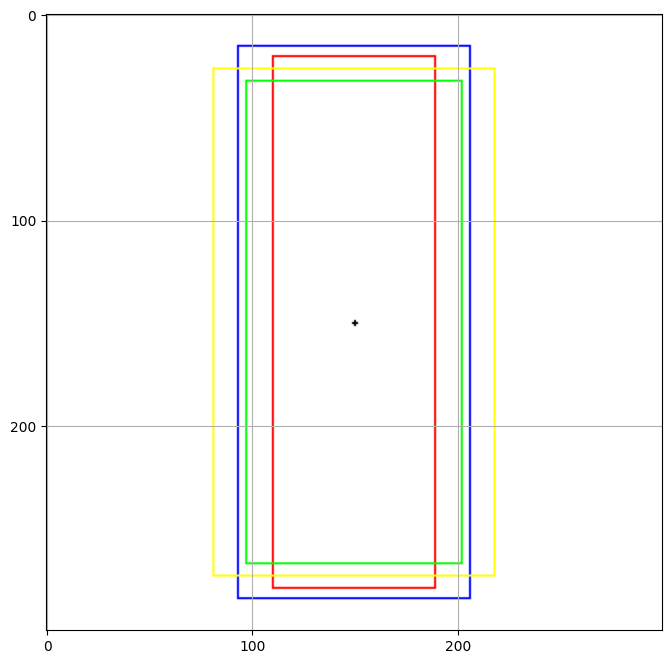

In [16]:
vis = VisulaizeAnchors(num_grid_cells = (3,3))
anchor_center = (150, 150)

# widht-height to origin centered anchor
anchors = wh_to_origin_centered_anchors(anchors_wh['3x3'])

# update the anchors position
anchors = add_offset_to_anchors(anchors, anchor_center)
vis.add_anchors(anchors)
vis.add_center(anchor_center)
vis.imshow()

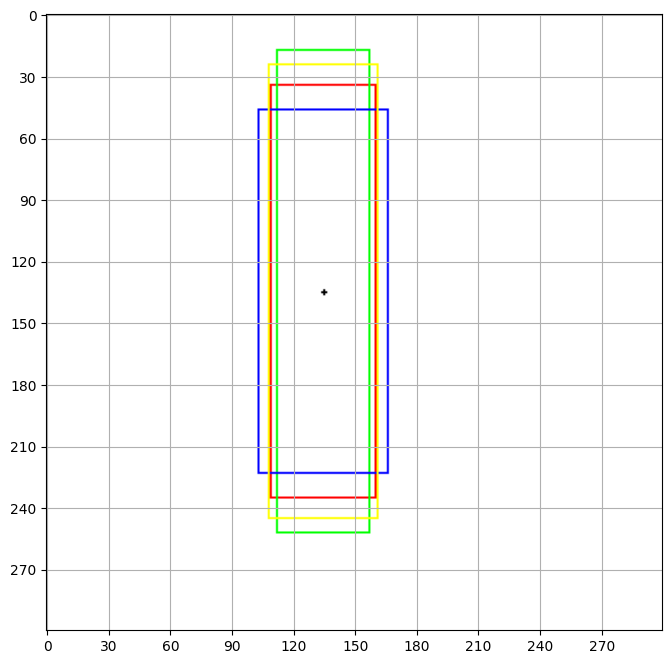

In [19]:
vis = VisulaizeAnchors(num_grid_cells=(10, 10))
anchor_center = (135, 135)
# width-height to origin centered anchor
anchors = wh_to_origin_centered_anchors(anchors_wh['10x10'])
# update the anchors position
anchors = add_offset_to_anchors(anchors, anchor_center)
vis.add_anchors(anchors)
vis.add_center(anchor_center)
vis.imshow()